### Etude de la clusterisation des différents grands types cellulaires : Steroid cells, Myeloid cells, Fibroblasts, Endothelial cells.

In [ ]:
from scripts.utils import check_data, preprocess_data, save_data
from scripts.utils import PROJECT_PATH, DATA_PATH, RESULTS_PATH, CELLTYPE_MAP, HISTOTYPE_MAP, ANNDATA_MAP, SUBSETS_CONFIG

from scripts.gene_subsampling import neyman_subsample
from scripts.studies import study_sparsity, study_sparsity_with_trajectories, study_complete_sparsity, study_group_sparsity, study_group_sparsity_exclude
import numpy as np

from scripts.clustering import cluster_data, find_best_resolution, find_best_resolution_linspace, best_leiden_run

from scripts.utils import plot_UMAP, update_data
import os

%load_ext autoreload
%autoreload 2

#### Sélection de la donnée (celltype="all" importe l'ensemble du dataset sans filtrer sur le type cellulaire).

In [14]:
cells = check_data(celltype="all",data_path=DATA_PATH)
if cells is None:
    cells = preprocess_data(celltype="4principals", with_subsets_config=True, n_neighbors=15, n_comps=100, random_state=42, verbose=False)
    save_data(data=cells, data_path=f"{DATA_PATH}\\{ANNDATA_MAP['all']}")

In [15]:
cells

AnnData object with n_obs × n_vars = 168927 × 2421
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'cellstates_tme', 'histotype', 'celltype', 'celltype_normal_adrenal', 'celltype_label', 'histotype_label'
    var: 'features'
    uns: 'neighbors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances'

In [ ]:
### Application d'un léger filtre pour ne récupérer que les grands types cellulaires (Stéroides, Myéloïdes, Fibroblasts et Endothéliales)
cells = cells[cells.obs["celltype_label"].isin(["Steroid cells", "Myeloid cells", "Fibroblasts", "Endothelial cells"])]

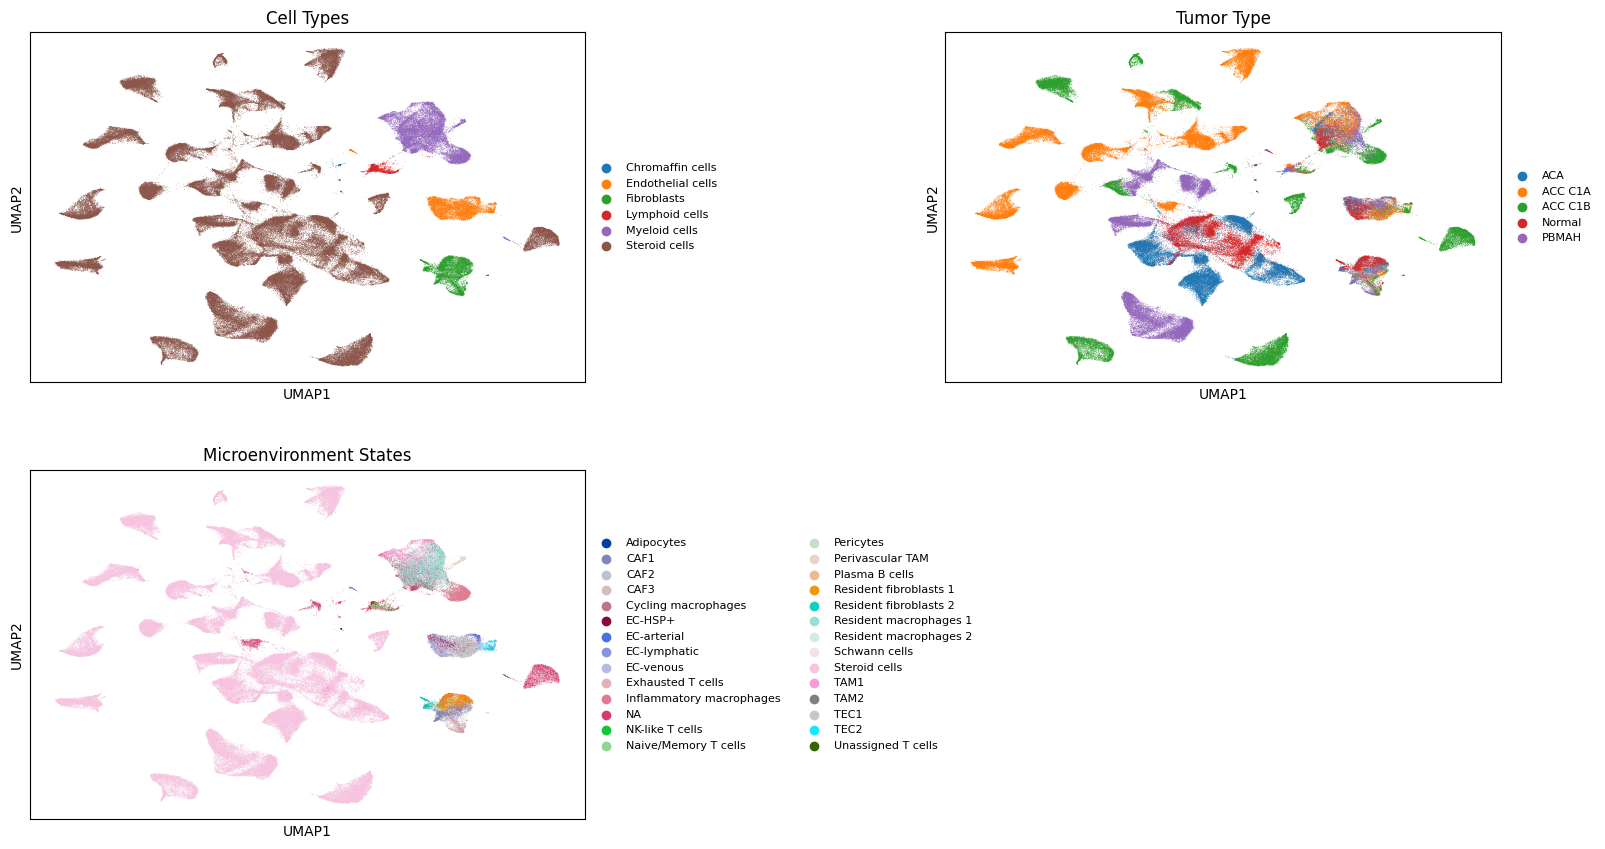

In [5]:
plot_UMAP(cells)

### Steroid cells vs All

In [17]:
n_cells=2e3
cells = neyman_subsample(data=cells,target_labels=["Steroid cells", "Fibroblasts", "Endothelial cells", "Myeloid cells"], label_col="celltype_label",stratify_by=["celltype_label"],n_target_total=n_cells)
#cells = update_data(data=cells)

In [18]:
cells = update_data(cells)

c:\Users\mayeu\Desktop\TRAVAIL\MVA\Cours\Projet médecin\scripts\scripts\utils.py:254: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  data.X = residuals
c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\scanpy\preprocessing\_pca\__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


AnnData object with n_obs × n_vars = 2000 × 2421
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'cellstates_tme', 'histotype', 'celltype', 'celltype_normal_adrenal', 'celltype_label', 'histotype_label'
    var: 'features'
    uns: 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [19]:
cells

AnnData object with n_obs × n_vars = 2000 × 2421
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'cellstates_tme', 'histotype', 'celltype', 'celltype_normal_adrenal', 'celltype_label', 'histotype_label'
    var: 'features'
    uns: 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [10]:
principals = ["Steroid cells", "Fibroblasts", "Endothelial cells", "Myeloid cells"]

cells[cells.obs["celltype_label"].isin(principals)]

View of AnnData object with n_obs × n_vars = 2000 × 2421
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'cellstates_tme', 'histotype', 'celltype', 'celltype_normal_adrenal', 'celltype_label', 'histotype_label'
    var: 'features'
    uns: 'neighbors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances'

c:\Users\mayeu\Desktop\TRAVAIL\MVA\Cours\Projet médecin\scripts\scripts\utils.py:271: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  data.obs['celltype_label'] = data.obs['celltype'].map(CELLTYPE_MAP).astype('category')


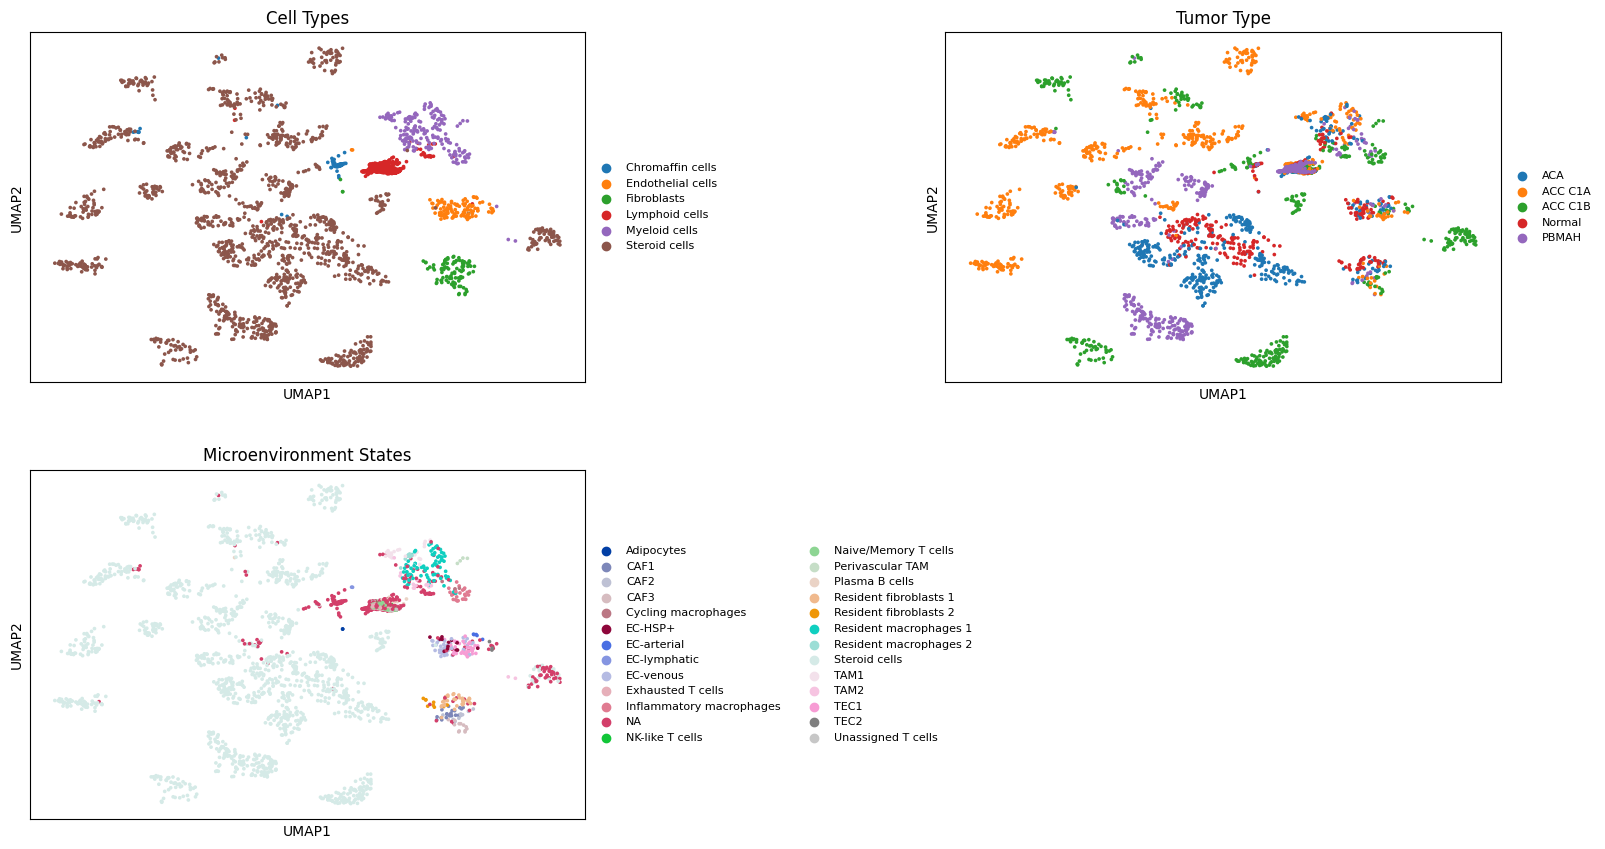

In [11]:
plot_UMAP(cells)

In [6]:
cells[cells.obs["celltype_label"] == "Endothelial cells"]

View of AnnData object with n_obs × n_vars = 107 × 2421
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'cellstates_tme', 'histotype', 'celltype', 'celltype_normal_adrenal', 'celltype_label', 'histotype_label'
    var: 'features'
    uns: 'neighbors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances'

In [26]:
cells.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_SCT,nFeature_SCT,cellstates_tme,histotype,celltype,celltype_normal_adrenal,celltype_label,histotype_label
ACA1_AAACGAACAAGATGTA,20,658.0,577,0.817439,2535.0,1054,NA,2,5,NA,Lymphoid cells,ACA
ACA1_AAAGGATAGCTGGCCT,20,524.0,454,0.164204,2449.0,1030,NA,2,5,NA,Lymphoid cells,ACA
ACA1_AAAGTCCTCGGCCCAA,20,1295.0,998,0.136893,2799.0,1081,NA,2,1,NA,Chromaffin cells,ACA
ACA1_AACCACATCACTTGTT,20,1107.0,843,0.000000,2693.0,1008,NA,2,5,NA,Lymphoid cells,ACA
ACA1_AACCACATCTCTCGCA,20,1178.0,858,0.900225,2683.0,983,Unassigned T cells,2,5,NA,Lymphoid cells,ACA
...,...,...,...,...,...,...,...,...,...,...,...,...
ACC10_TTTGACTCAGCGTACC,12,8235.0,3121,0.010435,3942.0,2343,Steroid cells,1,0,NA,Steroid cells,ACC C1B
ACA2_TACACCCTCAAAGACA,21,4842.0,2270,0.068552,3853.0,2270,Steroid cells,2,0,NA,Steroid cells,ACA
PBMAH5_CACTGGGCACTTGTGA,32,9373.0,3611,0.018290,3698.0,2295,Steroid cells,3,0,NA,Steroid cells,PBMAH
ACC5_CCAATGACACTTTAGG,6,2306.0,1544,0.037580,2925.0,1544,Steroid cells,0,0,NA,Steroid cells,ACC C1A


In [21]:
cells

AnnData object with n_obs × n_vars = 4246 × 2421
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'cellstates_tme', 'histotype', 'celltype', 'celltype_normal_adrenal', 'celltype_label', 'histotype_label'
    var: 'features'
    uns: 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [ ]:
labels = [0 if label=="Steroid cells" else 1 for label in cells.obs["celltype_label"]]
n_points_ratio = 20
n_runs = 75
n_neighbors_candidates = [15,25,50,100,200,300]

ratio_candidates = np.linspace(0.01,1,n_points_ratio)
show = True

sparsity_results = study_complete_sparsity(cells,labels=labels,ratio_candidates=ratio_candidates,n_runs=n_runs, n_neighbors_candidates=n_neighbors_candidates, show=show)

In [ ]:
# End
del cells

### Myeloid vs Fibroblast cells vs Endothelial cells

In [8]:
nosteroid_cells = check_data(celltype="No steroid",data_path=DATA_PATH)
if cells is None:
    cells = preprocess_data(celltype="No steroid", with_subsets_config=True, n_neighbors=15, n_comps=100, random_state=42, verbose=False)
    save_data(data=cells, data_path=f"{DATA_PATH}\\{ANNDATA_MAP['No steroid']}")

In [ ]:
n_points_ratio = 20
n_runs = 75
n_neighbors_candidates = [15,25,50,100,200,300]

ratio_candidates = np.linspace(0.01,1,n_points_ratio)
labels = nosteroid_cells.obs["celltype_label"]
show = True

sparsity_results = study_complete_sparsity(nosteroid_cells,labels=labels,ratio_candidates=ratio_candidates,n_runs=n_runs, n_neighbors_candidates=n_neighbors_candidates, show=show)

In [ ]:
n_points_ratio = 20
n_runs = 75
ratio_candidates = np.linspace(0.01,1,n_points_ratio)
n_neighbors=20
study_group_sparsity(nosteroid_cells,labels=labels,ratio_candidates=ratio_candidates,n_runs=n_runs, n_neighbors=n_neighbors, search_resolution_method="optuna", show=show)

In [ ]:
n_points_ratio = 20
n_runs = 75
ratio_candidates = np.linspace(0.01,1,n_points_ratio)
n_neighbors=20
study_group_sparsity_exclude(nosteroid_cells,labels=labels,ratio_candidates=ratio_candidates,n_runs=n_runs, n_neighbors=n_neighbors, search_resolution_method="optuna", show=show)